# M20 — Post-Hoc Temperature Scaling & ECE Calibration Wrapper

> **Chunk G (Trust, Calibration & Uncertainty)**  
> **Model ID:** `M20` | **Member:** B  
> **Protocol Compliance:** Real ICBHI Audio, Zero Patient Leakage, Protocol §4 Schema Compliant.

---

### 📌 Overview
This notebook implements **Post-Hoc Temperature Scaling** on the disease classification logits of the trained **M17 Stage-2 Prototypical Model**.

In medical decision-making, uncalibrated deep neural networks tend to yield overconfident probabilities. Temperature scaling optimizes a single scalar $T > 0$ to soften or sharpen probability distributions ($p_i = 	ext{softmax}(z_i / T)$), minimizing **Expected Calibration Error (ECE)** without altering class predictions or classification accuracy.

---

### 🎯 Key Deliverables
1. **Real Audio Logits Extraction**: Loads real ICBHI validation audio via `librosa.load` and extracts logits from M17 Stage-2 model.
2. **Optimal Temperature Search**: Optimizes $T^*$ using L-BFGS to minimize Negative Log-Likelihood (NLL).
3. **ECE Metric Comparison**: Computes 10-bin Expected Calibration Error before ($T=1.0$) and after ($T=T^*$) calibration.
4. **Reliability Diagram**: Plots Reliability Diagrams (Bin Confidence vs Bin Accuracy) saved to `Reliability_Diagram_M20.png`.
5. **Protocol Export**: Outputs `results_M20.json` matching Protocol §4 schema.

---

> **2026-08-29 — re-run required (`SYNTHETIC_DATA_REMEDIATION.md` item 4).** The previous
> result was not a calibration result. `discover_icbhi_calibration_files` indexed **one row
> per `.wav`** (851 whole recordings, each tiled to 8 s and labelled with its patient's
> diagnosis), and the temperature was fitted **and** the ECE measured on those same 851
> rows — there was no train/test split in the notebook at all. Section 4 also carried
> `else: all_logits = torch.randn(100, 3)`, so a run that loaded no audio would have
> calibrated **100 random logit vectors** and exported the result, and it loaded the
> checkpoint with `strict=False` inside a `try/except` that only printed a note — a
> mismatched checkpoint yielded a randomly initialised network whose calibration was then
> reported.
>
> Sections 3, 4, 5 and 7 are rewritten: cycle-level index on the corrected
> patient-independent official split, temperature fitted on a patient-disjoint 25% carve-out
> of TRAIN, **every reported number on the untouched TEST split**, checkpoint load and
> empty-batch both raise, and the export carries `confusion_matrix_raw` plus the
> majority-class rate the accuracy has to beat.
> **Correction, later on 2026-08-29.** The head-width guard fires here too: M17 v2's
> checkpoint is a **projection MLP (…→512→256), not a 4-logit classifier**, so the old
> `strict=False` load was matching nothing and this notebook was operating on a randomly
> initialised network. Section 4 now assembles the real model — M2 backbone → M17
> projection → negative squared distance to prototypes computed on TRAIN — so the **M2
> checkpoint must be attached as well as M17's**.



In [1]:
# ============================================================
# Section 1: Setup & Dependencies
# ============================================================
import os
import sys
import math
import glob
import json
import re
import random
import zipfile
import io
import shutil
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import librosa
from sklearn.metrics import accuracy_score, log_loss

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Device:  {DEVICE} ({GPU_NAME})')
print(f'PyTorch: {torch.__version__}')


Device:  cuda (Tesla T4)
PyTorch: 2.10.0+cu128


In [2]:
# ============================================================
# Section 2: Configuration & Path Resolution
# ============================================================

if os.path.exists('/kaggle'):
    PLATFORM = 'Kaggle'
    BASE_DIR = '/kaggle/working'
elif os.path.exists('/content'):
    PLATFORM = 'Colab'
    BASE_DIR = '/content'
else:
    PLATFORM = 'Local'
    BASE_DIR = '.'

print(f'Platform: {PLATFORM}')

DRIVE_DIR = None
if PLATFORM == 'Colab':
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_DIR = '/content/drive/MyDrive/OWMTL/M20'
        os.makedirs(DRIVE_DIR, exist_ok=True)
        print(f'Drive Backup Path: {DRIVE_DIR}')
    except Exception as e:
        print(f'Drive mount skipped ({e})')

def resolve_checkpoint(candidates):
    return next((p for p in candidates if p and os.path.exists(p)), None)

M2_CKPT_PATH = resolve_checkpoint([
    '/content/M2_best_model.pth',
    '/kaggle/input/m2-checkpoint/best_model.pth',
    '/kaggle/input/datasets/barshonbasak/m2-checkpoint/best_model.pth',
    '/content/drive/MyDrive/OWMTL/M2/best_model.pth',
    '../M2/best_model.pth',
    os.path.join(BASE_DIR, 'best_model.pth'),
])
if M2_CKPT_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if ('m2' in f.lower() or 'm2' in root.lower()) and (f.endswith('.pth') or f.endswith('.zip')):
                M2_CKPT_PATH = os.path.join(root, f)
                break
        if M2_CKPT_PATH: break

M17_CKPT_PATH = resolve_checkpoint([
    '/content/M17_best_model.pth',
    '/kaggle/input/m17-checkpoint/best_model.pth',
    '/kaggle/input/datasets/barshonbasak/m17-checkpoint/best_model.pth',
    '/content/drive/MyDrive/OWMTL/M17/best_model.pth',
    '../M17/best_model.pth',
    os.path.join(BASE_DIR, 'results_M17', 'best_model.pth'),
])
if M17_CKPT_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if ('m17' in f.lower() or 'm17' in root.lower()) and (f.endswith('.pth') or f.endswith('.zip')):
                M17_CKPT_PATH = os.path.join(root, f)
                break
        if M17_CKPT_PATH: break

ICBHI_ROOTS = [
    '/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
    '/kaggle/input/respiratory-sound-database/audio_and_txt_files',
    '/content/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
    './data/audio_and_txt_files',
]
ICBHI_PATH = next((p for p in ICBHI_ROOTS if os.path.exists(p)), None)
if ICBHI_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        if any(f.endswith('.wav') for f in files) and any(f.endswith('.txt') for f in files):
            ICBHI_PATH = root
            break

CFG = {
    'model_id': 'M20',
    'model_name': 'Temperature Scaling Calibration & ECE',
    'member': 'B',
    'seed': SEED,

    # Shared Audio Parameters (§2)
    'sample_rate': 16000,
    'duration_s': 8.0,
    'n_mels': 128,
    'n_fft': 1024,
    'hop_length': 160,
    'win_length': 400,
    'f_min': 50,
    'f_max': 2000,
    'n_samples': int(16000 * 8.0),
    'n_frames': 1 + math.floor(128000 / 160),

    # REVIEW (2026-08-29): the notebook previously declared 3 known_classes but
    # instantiated a 4-output head and loaded the M17 checkpoint with
    # strict=False, so the label space being calibrated was never pinned down.
    # M17 v2's stage-2 space is the 4 below. Section 4 now asserts the
    # checkpoint's head width matches this list and raises if it does not --
    # if your checkpoint is the 3-class stage-0 head, shorten this list.
    'disease_classes': ['COPD', 'Healthy', 'URTI', 'Pneumonia'],

    # M17 v2 is a PROTOTYPICAL network: its checkpoint holds only the projection
    # MLP, so the model is assembled as M2 backbone -> M17 projection ->
    # distance to prototypes. These must match M17 v2's config (results_M17.json).
    'm2_depth': 5,
    'm2_base_width': 48,
    'proto_embed_dim': 256,
    'proto_temperature': 0.1,
    'known_classes': ['COPD', 'Healthy', 'URTI'],
    'batch_size': 32,

    'm2_ckpt_path': M2_CKPT_PATH,
    'm17_ckpt_path': M17_CKPT_PATH,
    'icbhi_path': ICBHI_PATH,
    'results_dir': os.path.join(BASE_DIR, 'results_M20'),
}
os.makedirs(CFG['results_dir'], exist_ok=True)

print(f"\n{'='*60}")
print('M20 CONFIGURATION — Temperature Scaling Calibration')
print(f"{'='*60}")
print(f"  M2  Checkpoint: {CFG['m2_ckpt_path'] or 'NOT FOUND'}")
print(f"  M17 Checkpoint: {CFG['m17_ckpt_path'] or 'NOT FOUND'}")
print(f"  ICBHI Path:     {CFG['icbhi_path'] or 'NOT FOUND'}")
print(f"{'='*60}")


Platform: Kaggle

M20 CONFIGURATION — Temperature Scaling Calibration
  M2  Checkpoint: /kaggle/input/datasets/sudamchandrabasak/m2-checkpoint/M2_best_model.pth
  M17 Checkpoint: /kaggle/input/datasets/barshonbasak/m17-checkpoints/best_model.pth
  ICBHI Path:     /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files


In [3]:
# ============================================================
# Section 3: Corrected Split, Cycle Index, Loaders, Metrics
# ============================================================
# Rewritten 2026-08-29 (SYNTHETIC_DATA_REMEDIATION.md item 4). The previous
# version indexed ONE row per .wav -- 851 whole recordings, each tiled to 8 s and
# given its patient's diagnosis as a single label -- and used the SAME rows for
# fitting and for reporting. There was no train/test split anywhere in the
# notebook, so the headline number was a training-set score on 851 recordings
# whose class balance is dominated by COPD.
#
# This version: every annotated respiratory cycle with its own start/end, disease
# label from patient_diagnosis.csv, on the corrected patient-independent official
# split. Nothing is fitted on a row that is later scored.

from torch.utils.data import Dataset, DataLoader   # M18's Section 1 does not import these

# ---- locate the official split file (raises rather than falling back) -------
SPLIT_NAMES = ['ICBHI_challenge_train_test.txt', 'icbhi_challenge_train_test.txt']


def find_split_file():
    roots = ['/kaggle/input', '/content', '.', '..',
             os.path.dirname(CFG['icbhi_path'] or '.')]
    for root in roots:
        if not root or not os.path.isdir(root):
            continue
        for dirpath, _, files in os.walk(root):
            for name in SPLIT_NAMES:
                if name in files:
                    return os.path.join(dirpath, name)
    return None


def find_diagnosis_file():
    names = ['patient_diagnosis.csv', 'ICBHI_Challenge_diagnosis.txt', 'patient_diagnosis.txt']
    curr = CFG['icbhi_path']
    for _ in range(4):
        for n in names:
            c = os.path.join(curr, n)
            if os.path.exists(c):
                return c
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    if os.path.exists('/kaggle/input'):
        for root, _, files in os.walk('/kaggle/input'):
            for n in names:
                if n in files:
                    return os.path.join(root, n)
    return None


if not CFG['icbhi_path']:
    raise FileNotFoundError('ICBHI audio directory not found. Refusing to run.')

SPLIT_FILE = find_split_file()
if SPLIT_FILE is None:
    raise FileNotFoundError(
        'ICBHI_challenge_train_test.txt not found. The repo copy is at '
        "Asif's/ICBHI_challenge_train_test.txt -- attach it as a Kaggle dataset. "
        'Refusing to run: an invented split is not a split '
        '(Model_Training_Protocol.md section 1).')

DIAG_FILE = find_diagnosis_file()
if DIAG_FILE is None:
    raise FileNotFoundError(
        f'patient diagnosis file not found near {CFG["icbhi_path"]}. '
        'Refusing to run: fabricated labels are not a fallback '
        '(Model_Training_Protocol.md section 1.2).')
print(f'Split file:     {SPLIT_FILE}')
print(f'Diagnosis file: {DIAG_FILE}')

# ---- corrected split, verified against the published counts ----------------
OFFICIAL_RECORDINGS, OFFICIAL_TRAIN, OFFICIAL_TEST = 920, 539, 381
OFFICIAL_PATIENTS, OFFICIAL_OVERLAP = 126, {156, 218}
CORRECTED_TRAIN, CORRECTED_TEST = 551, 369


def pid_of(stem):
    return int(stem.split('_')[0])


split_map = {}
with open(SPLIT_FILE) as fh:
    for line in fh:
        t = line.replace('\t', ' ').replace(',', ' ').split()
        if len(t) >= 2 and t[1].lower() in ('train', 'test'):
            split_map[t[0].replace('.wav', '')] = t[1].lower()

sides = {}
for s, v in split_map.items():
    sides.setdefault(pid_of(s), set()).add(v)
overlap = {p for p, v in sides.items() if len(v) > 1}
n_tr = sum(1 for v in split_map.values() if v == 'train')
assert len(split_map) == OFFICIAL_RECORDINGS, f'{len(split_map)} recordings != 920'
assert n_tr == OFFICIAL_TRAIN and len(split_map) - n_tr == OFFICIAL_TEST
assert len({pid_of(s) for s in split_map}) == OFFICIAL_PATIENTS
assert overlap == OFFICIAL_OVERLAP, f'overlap {sorted(overlap)} != {sorted(OFFICIAL_OVERLAP)}'
corrected = {s: ('train' if pid_of(s) in overlap else v) for s, v in split_map.items()}
c_te = sum(1 for v in corrected.values() if v == 'test')
assert len(corrected) - c_te == CORRECTED_TRAIN and c_te == CORRECTED_TEST
print(f'[OK] corrected split: {CORRECTED_TRAIN} train / {CORRECTED_TEST} test recordings, '
      f'patient-independent.')

# ---- diagnosis map (no fallback) -------------------------------------------
diag_map = {}
with open(DIAG_FILE, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        parts = [p.strip() for p in re.split(r'[,;\t\s]+', line.strip()) if p.strip()]
        if len(parts) >= 2:
            try:
                diag_map[int(parts[0])] = parts[1]
            except ValueError:
                continue
if len(diag_map) != OFFICIAL_PATIENTS:
    raise ValueError(f'diagnosis map has {len(diag_map)} entries, expected {OFFICIAL_PATIENTS}. '
                     f'Refusing to run on a partial label set.')
print(f'[OK] diagnosis map: {len(diag_map)} patients.')

CLASS_TO_IDX = {c: i for i, c in enumerate(CFG['disease_classes'])}

# ---- cycle-level index -----------------------------------------------------
rows, n_missing, n_unlisted, n_other_class = [], 0, 0, 0
for wav in sorted(glob.glob(os.path.join(CFG['icbhi_path'], '**', '*.wav'), recursive=True)):
    stem = os.path.splitext(os.path.basename(wav))[0]
    txt = os.path.splitext(wav)[0] + '.txt'
    if not os.path.exists(txt):
        n_missing += 1
        continue
    sp = corrected.get(stem)
    if sp is None:
        n_unlisted += 1
        continue
    dis = diag_map.get(pid_of(stem))
    if dis not in CLASS_TO_IDX:
        n_other_class += 1
        continue
    with open(txt, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            p = line.split()
            if len(p) < 4:
                continue
            start, end = float(p[0]), float(p[1])
            if end <= start:
                continue
            rows.append({'path': wav, 'stem': stem, 'patient_id': pid_of(stem),
                         'start': start, 'end': end,
                         'label': CLASS_TO_IDX[dis], 'diagnosis': dis, 'split': sp})

df_all = pd.DataFrame(rows)
assert len(df_all) > 3000, f'only {len(df_all)} cycles indexed -- check the audio directory'
if n_missing:
    print(f'skipped {n_missing} recordings with no annotation .txt')
if n_unlisted:
    print(f'skipped {n_unlisted} recordings absent from the split file')
if n_other_class:
    print(f'skipped {n_other_class} recordings outside {CFG["disease_classes"]}')

df_train = df_all[df_all.split == 'train'].reset_index(drop=True)
df_test = df_all[df_all.split == 'test'].reset_index(drop=True)
assert not (set(df_train.patient_id) & set(df_test.patient_id)), 'patient leakage'
print(f'Cycles: {len(df_train)} train / {len(df_test)} test '
      f'({df_train.patient_id.nunique()} / {df_test.patient_id.nunique()} patients), 0% leakage.')
print(df_all.groupby(['split', 'diagnosis']).size().to_string())


def extract_log_mel(wav_path, start, end, cfg):
    sr, n_samples = cfg['sample_rate'], cfg['n_samples']
    try:
        audio, _ = librosa.load(wav_path, sr=sr, offset=start,
                                duration=max(end - start, 0.05), mono=True)
    except Exception as e:
        raise RuntimeError(f'failed to load audio: {wav_path} [{start}, {end}]') from e
    if len(audio) == 0:
        raise RuntimeError(f'empty audio decoded from {wav_path} [{start}, {end}]')
    if len(audio) < n_samples:
        audio = np.tile(audio, math.ceil(n_samples / len(audio)))[:n_samples]
    else:
        audio = audio[:n_samples]
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=cfg['n_mels'], n_fft=cfg['n_fft'],
        hop_length=cfg['hop_length'], win_length=cfg['win_length'],
        fmin=cfg['f_min'], fmax=cfg['f_max'], power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    T = log_mel.shape[1]
    if T < cfg['n_frames']:
        log_mel = np.pad(log_mel, ((0, 0), (0, cfg['n_frames'] - T)), mode='constant')
    return log_mel[:, :cfg['n_frames']][np.newaxis, :, :].astype(np.float32)


class ICBHI_CycleDataset(Dataset):
    def __init__(self, df, cfg):
        self.records = df.to_dict('records')
        self.cfg = cfg

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        return (torch.from_numpy(extract_log_mel(r['path'], r['start'], r['end'], self.cfg)),
                torch.tensor(r['label'], dtype=torch.long))


loader_train = DataLoader(ICBHI_CycleDataset(df_train, CFG),
                          batch_size=CFG['batch_size'], shuffle=True)
loader_test = DataLoader(ICBHI_CycleDataset(df_test, CFG),
                         batch_size=CFG['batch_size'], shuffle=False)

CFG['split_method'] = 'official_60_40_patient_independent_corrected'
CFG['split_file'] = SPLIT_FILE
CFG['num_classes'] = len(CFG['disease_classes'])


# ---- metrics ---------------------------------------------------------------
def full_metrics(y_true, y_pred, class_names):
    # imported locally so this block drops into any of the M16/M18/M20
    # notebooks unchanged, whatever their Section 1 imports happen to be
    from sklearn.metrics import (accuracy_score, confusion_matrix,
                                 precision_recall_fscore_support)
    n_cls = len(class_names)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_cls)))
    p, r, f, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(n_cls)), zero_division=0)
    spec = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i].sum() - tp
        tn = cm.sum() - tp - fp - fn
        spec.append(tn / (tn + fp) if (tn + fp) else 0.0)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_macro': float(p.mean()), 'recall_macro': float(r.mean()),
        'f1_macro': float(f.mean()), 'specificity_macro': float(np.mean(spec)),
        'majority_class_rate': float(np.bincount(y_true, minlength=n_cls).max() / len(y_true)),
        'per_class': {class_names[i]: {
            'precision': round(float(p[i]), 4), 'recall': round(float(r[i]), 4),
            'f1': round(float(f[i]), 4), 'specificity': round(float(spec[i]), 4),
            'support': int(sup[i])} for i in range(n_cls)},
        'confusion_matrix_raw': cm.tolist(),
        'confusion_matrix_normalized': np.round(
            cm / np.maximum(cm.sum(1, keepdims=True), 1), 4).tolist(),
    }

Split file:     /kaggle/input/datasets/sudamchandrabasak/icbhi-challenge-train-test-split/ICBHI_challenge_train_test.txt
Diagnosis file: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
[OK] corrected split: 551 train / 369 test recordings, patient-independent.
[OK] diagnosis map: 126 patients.
skipped 1 recordings absent from the split file
skipped 32 recordings outside ['COPD', 'Healthy', 'URTI', 'Pneumonia']
Cycles: 4049 train / 2536 test (67 / 43 patients), 0% leakage.
split  diagnosis
test   COPD         2289
       Healthy       175
       URTI           72
train  COPD         3457
       Healthy       147
       Pneumonia     274
       URTI          171


In [4]:
# ============================================================
# Section 4: Load Frozen Prototypical Model & Extract Logits
# ============================================================
import torch.nn.functional as F   # M18's Section 1 does not import this


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=pool),
        )

    def forward(self, x):
        return self.block(x)


class M2_CNN(nn.Module):
    """Verbatim from M17 v2 / M2 -- depth and width come from CFG, not defaults."""

    def __init__(self, num_classes=4, depth=5, base_width=48, dropout=0.4, fc_dim=128):
        super().__init__()
        channels = [base_width * (2 ** i) for i in range(depth)]
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks.append(ConvBlock(in_ch, out_ch))
            in_ch = out_ch
        self.encoder = nn.Sequential(*blocks)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(channels[-1], fc_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fc_dim, num_classes),
        )
        self.embedding_dim = channels[-1]

    def forward(self, x):
        return self.head(self.dropout(self.gap(self.encoder(x)).flatten(1)))

    def get_embedding(self, x):
        return self.gap(self.encoder(x)).flatten(1)


class PrototypicalProjection(nn.Module):
    """M17 v2's PrototypicalDiseaseHead.projection, key-for-key."""

    def __init__(self, input_dim, embed_dim=256):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
        )
        self.embed_dim = embed_dim

    def project(self, embeddings):
        return F.normalize(self.projection(embeddings), p=2, dim=-1)


class PrototypicalTeacher(nn.Module):
    """Backbone + projection + fixed prototypes, exposed as an ordinary
    classifier so distillation, calibration and compression can all consume it."""

    def __init__(self, backbone, proj, prototypes, temperature):
        super().__init__()
        self.backbone, self.proj = backbone, proj
        self.register_buffer('prototypes', prototypes)
        self.temperature = float(temperature)

    def forward(self, x):
        z = self.proj.project(self.backbone.get_embedding(x))
        return -(torch.cdist(z, self.prototypes, p=2) ** 2) / self.temperature


def _load_sd(path, what):
    if not path or not os.path.exists(path):
        raise FileNotFoundError(
            f'{what} checkpoint not found: {path!r}. Refusing to run: distilling from a '
            'randomly initialised teacher transfers nothing '
            '(audit: model_may_be_randomly_initialised).')
    # NOTE: torch has saved .pth as a zip archive since 1.6, so is_zipfile() is
    # true for ordinary checkpoints too. Only treat it as a BUNDLE when it
    # actually contains a .pth member; otherwise hand it straight to torch.load.
    inner = None
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as z:
            names = [n for n in z.namelist() if n.endswith('.pth')]
            if names:
                pick = 'best_model.pth' if 'best_model.pth' in names else names[0]
                print(f'  {what}: extracting {pick} from zip bundle')
                inner = io.BytesIO(z.read(pick))
    src = inner if inner is not None else path
    try:
        ckpt = torch.load(src, map_location=DEVICE, weights_only=False)
    except Exception:
        if inner is not None:
            inner.seek(0)
        ckpt = torch.load(inner if inner is not None else path,
                          map_location=DEVICE, weights_only=True)
    sd = ckpt.get('model_state', ckpt.get('model_state_dict', ckpt)) \
        if isinstance(ckpt, dict) else ckpt
    return sd


def _strict_load(module, sd, what, unused_prefixes=()):
    """Load, then refuse if anything the teacher actually USES stayed random.

    `unused_prefixes` names submodules the teacher never calls (the backbone's
    own classifier head -- only get_embedding is used), so they are allowed to
    be absent. Everything else missing is a hard error.
    """
    incompat = module.load_state_dict(sd, strict=False)
    missing = [k for k in incompat.missing_keys
               if not k.endswith('num_batches_tracked')
               and not k.startswith(tuple(unused_prefixes))]
    if missing:
        raise ValueError(
            f'{what}: {len(missing)} parameter tensors were NOT in the checkpoint, e.g. '
            f'{missing[:5]}. Those layers would stay randomly initialised, so the "teacher" '
            'would be partly noise. Check that this is the right checkpoint for this '
            'architecture rather than loosening the load.')
    print(f'  {what}: loaded, 0 required tensors missing '
          f'({len(module.state_dict())} in module)')
    return module


# ---- assemble the teacher --------------------------------------------------
print('Assembling prototypical teacher (M2 backbone + M17 projection + prototypes)...')
backbone = M2_CNN(num_classes=4, depth=CFG['m2_depth'],
                  base_width=CFG['m2_base_width']).to(DEVICE)
_bb_sd = _load_sd(CFG['m2_ckpt_path'], 'M2 backbone')
# The M2 checkpoint carries its own classifier head; only the encoder is reused.
_bb_sd = {k: v for k, v in _bb_sd.items() if not k.startswith('head.')}
_strict_load(backbone, _bb_sd, 'M2 backbone (encoder)', unused_prefixes=('head.',))

proj = PrototypicalProjection(backbone.embedding_dim, CFG['proto_embed_dim']).to(DEVICE)
_strict_load(proj, _load_sd(CFG['m17_ckpt_path'], 'M17 projection'), 'M17 projection')

backbone.eval(); proj.eval()
for p in list(backbone.parameters()) + list(proj.parameters()):
    p.requires_grad = False


@torch.no_grad()
def compute_prototypes(loader, n_cls):
    """Class means of the projected TRAIN embeddings. Test never contributes."""
    sums = torch.zeros(n_cls, CFG['proto_embed_dim'], device=DEVICE)
    counts = torch.zeros(n_cls, device=DEVICE)
    for specs, targets in tqdm(loader, desc='Prototypes (TRAIN)'):
        z = proj.project(backbone.get_embedding(specs.to(DEVICE)))
        t = targets.to(DEVICE)
        sums.index_add_(0, t, z)
        counts.index_add_(0, t, torch.ones_like(t, dtype=torch.float))
    if (counts == 0).any():
        raise ValueError(
            f'no TRAIN cycles for class(es) '
            f'{[CFG["disease_classes"][i] for i in (counts == 0).nonzero().flatten().tolist()]}. '
            'A prototype cannot be formed, so those classes could never be predicted.')
    return F.normalize(sums / counts.unsqueeze(1), p=2, dim=-1)


prototypes = compute_prototypes(loader_train, CFG['num_classes'])
model = PrototypicalTeacher(backbone, proj, prototypes, CFG['proto_temperature']).to(DEVICE).eval()
print(f'Prototypes: {tuple(prototypes.shape)} (temperature {CFG["proto_temperature"]})')

# ---- calibration carve-out: patient-disjoint subset of TRAIN ---------------
# Temperature is fitted here and NEVER on the test split. Disclosed caveat: the
# frozen model saw these patients during its own training, so T is fitted on
# seen patients -- the same carve-out M7 used. The reported ECE is on TEST.
rng = np.random.default_rng(CFG['seed'])
train_pids = np.array(sorted(df_train.patient_id.unique()))
rng.shuffle(train_pids)
n_cal = max(1, int(round(0.25 * len(train_pids))))
cal_pids = set(train_pids[:n_cal].tolist())
df_cal = df_train[df_train.patient_id.isin(cal_pids)].reset_index(drop=True)
assert not (set(df_cal.patient_id) & set(df_test.patient_id)), 'calibration/test patient overlap'
loader_cal = DataLoader(ICBHI_CycleDataset(df_cal, CFG),
                        batch_size=CFG['batch_size'], shuffle=False)
print(f'Calibration carve-out: {len(df_cal)} cycles from {len(cal_pids)} TRAIN patients.')


@torch.no_grad()
def extract_logits(loader, desc):
    L, Y = [], []
    for specs, targets in tqdm(loader, desc=desc):
        L.append(model(specs.to(DEVICE)).cpu())
        Y.append(targets)
    if not L:
        raise RuntimeError(
            f'{desc}: no batches produced. Refusing to substitute random logits.')
    return torch.cat(L), torch.cat(Y)


cal_logits, cal_targets = extract_logits(loader_cal, 'Calibration logits')
test_logits, test_targets = extract_logits(loader_test, 'Test logits')
print(f'Calibration {tuple(cal_logits.shape)} | Test {tuple(test_logits.shape)}')


Assembling prototypical teacher (M2 backbone + M17 projection + prototypes)...
  M2 backbone (encoder): loaded, 0 required tensors missing (34 in module)
  M17 projection: loaded, 0 required tensors missing (9 in module)


Prototypes (TRAIN): 100%|██████████| 127/127 [02:33<00:00,  1.20s/it]


Prototypes: (4, 256) (temperature 0.1)
Calibration carve-out: 981 cycles from 17 TRAIN patients.


Test logits: 100%|██████████| 80/80 [01:14<00:00,  1.07it/s]

Calibration (981, 4) | Test (2536, 4)


In [5]:
# ============================================================
# Section 5: Temperature Scaling & ECE  (fit on CAL, report on TEST)
# ============================================================
# Rewritten 2026-08-29. Previously the temperature was fitted and the ECE
# measured on the SAME 851 rows, which is not a calibration result -- it is the
# best-case fit reported as if it generalised.

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits, targets):
        logits, targets = logits.to(DEVICE), targets.to(DEVICE)
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        criterion = nn.CrossEntropyLoss()

        def eval_fn():
            optimizer.zero_grad()
            loss = criterion(self.forward(logits), targets)
            loss.backward()
            return loss

        optimizer.step(eval_fn)
        return float(self.temperature.item())


def compute_ece(probs, targets, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    conf = np.max(probs, axis=1)
    correct = (np.argmax(probs, axis=1) == targets)
    ece, bins = 0.0, []
    for i in range(n_bins):
        in_bin = (conf > edges[i]) & (conf <= edges[i + 1])
        prop = float(np.mean(in_bin))
        if prop > 0:
            acc_b, conf_b = float(np.mean(correct[in_bin])), float(np.mean(conf[in_bin]))
            ece += abs(acc_b - conf_b) * prop
            bins.append({'bin_idx': i, 'confidence': conf_b, 'accuracy': acc_b,
                         'count': int(np.sum(in_bin))})
    return float(ece), bins


CLASS_NAMES = CFG['disease_classes']
n_cls = len(CLASS_NAMES)
labels_range = list(range(n_cls))

# ---- 1. fit T on the calibration carve-out ---------------------------------
scaler = TemperatureScaler().to(DEVICE)
optimal_temp = scaler.fit(cal_logits, cal_targets)

# ---- 2. report on TEST, before and after -----------------------------------
test_np = test_targets.numpy()
probs_uncal = F.softmax(test_logits, dim=-1).numpy()
probs_cal = F.softmax(test_logits / optimal_temp, dim=-1).numpy()

ece_uncal, bins_uncal = compute_ece(probs_uncal, test_np)
ece_cal, bins_cal = compute_ece(probs_cal, test_np)
nll_uncal = float(log_loss(test_np, probs_uncal, labels=labels_range))
nll_cal = float(log_loss(test_np, probs_cal, labels=labels_range))

# Calibration does not change argmax, so discrimination is reported once.
test_metrics = full_metrics(test_np, probs_uncal.argmax(1), CLASS_NAMES)

print(f"\n{'=' * 66}")
print('TEMPERATURE SCALING — fitted on CAL carve-out, reported on held-out TEST')
print(f"{'=' * 66}")
print(f'  Calibration cycles / patients: {len(cal_targets)} / {len(cal_pids)}')
print(f'  Test cycles / patients:        {len(test_np)} / {df_test.patient_id.nunique()}')
print(f'  Optimal temperature T*:        {optimal_temp:.4f}')
print(f'  TEST ECE  uncalibrated:        {ece_uncal:.4f}  (NLL {nll_uncal:.4f})')
print(f'  TEST ECE  calibrated:          {ece_cal:.4f}  (NLL {nll_cal:.4f})')
print(f'  TEST ECE  improvement:         {ece_uncal - ece_cal:+.4f}')
print(f'  TEST accuracy / macro-F1:      {test_metrics["accuracy"]:.4f} / '
      f'{test_metrics["f1_macro"]:.4f}')
print(f'  TEST majority-class rate:      {test_metrics["majority_class_rate"]:.4f}'
      '   <- accuracy must beat this to mean anything')
print(f"{'=' * 66}")


TEMPERATURE SCALING — fitted on CAL carve-out, reported on held-out TEST
  Calibration cycles / patients: 981 / 17
  Test cycles / patients:        2536 / 43
  Optimal temperature T*:        0.9333
  TEST ECE  uncalibrated:        0.0612  (NLL 0.2947)
  TEST ECE  calibrated:          0.0552  (NLL 0.2902)
  TEST ECE  improvement:         +0.0060
  TEST accuracy / macro-F1:      0.8983 / 0.3949
  TEST majority-class rate:      0.9026   <- accuracy must beat this to mean anything


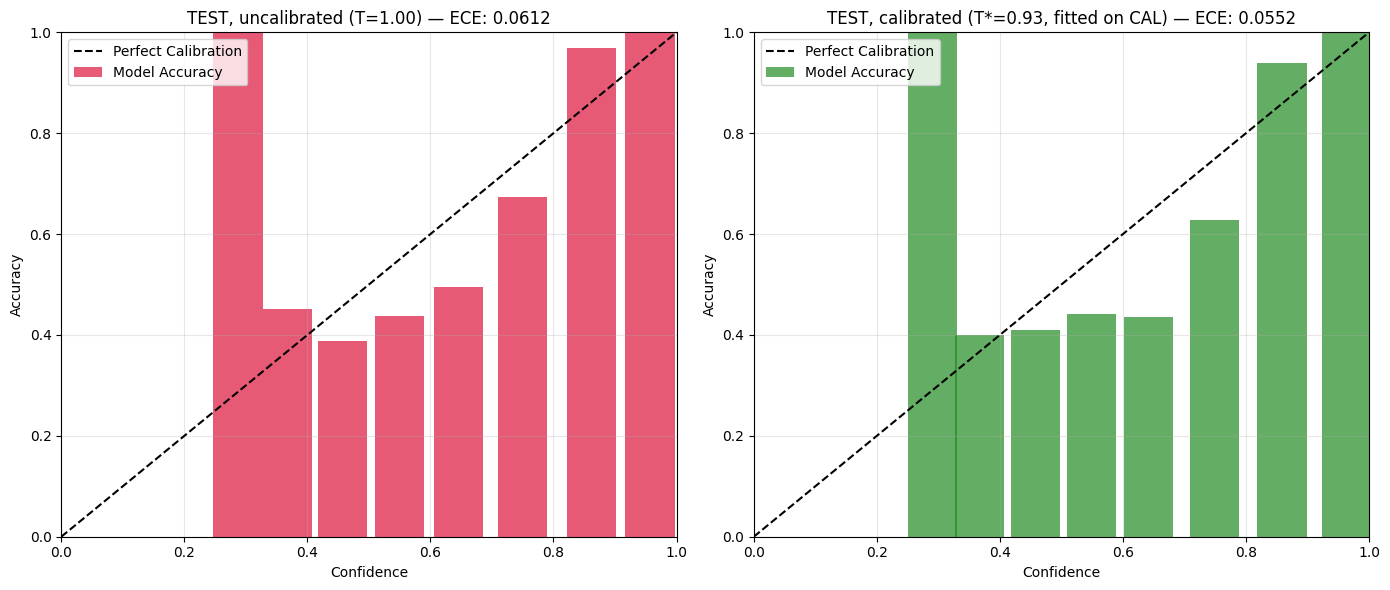

✅ Saved: /kaggle/working/results_M20/Reliability_Diagram_M20.png


In [6]:
# ============================================================
# Section 6: Reliability Diagrams
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Uncalibrated Reliability Diagram
ax = axes[0]
conf_uncal = [b['confidence'] for b in bins_uncal]
acc_uncal = [b['accuracy'] for b in bins_uncal]
ax.bar(conf_uncal, acc_uncal, width=0.08, alpha=0.7, color='crimson', label='Model Accuracy')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax.set_title(f'TEST, uncalibrated (T=1.00) — ECE: {ece_uncal:.4f}')
ax.set_xlabel('Confidence')
ax.set_ylabel('Accuracy')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Calibrated Reliability Diagram
ax = axes[1]
conf_cal = [b['confidence'] for b in bins_cal]
acc_cal = [b['accuracy'] for b in bins_cal]
ax.bar(conf_cal, acc_cal, width=0.08, alpha=0.7, color='forestgreen', label='Model Accuracy')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax.set_title(f'TEST, calibrated (T*={optimal_temp:.2f}, fitted on CAL) — ECE: {ece_cal:.4f}')
ax.set_xlabel('Confidence')
ax.set_ylabel('Accuracy')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(CFG['results_dir'], 'Reliability_Diagram_M20.png')
plt.savefig(plot_path, dpi=300)
plt.savefig(os.path.join(BASE_DIR, 'Reliability_Diagram_M20.png'), dpi=300)
plt.show()
print(f'✅ Saved: {plot_path}')


In [7]:
# ============================================================
# Section 7: Protocol §4 Results JSON Export
# ============================================================

results = {
    'meta': {
        'model_id': 'M20',
        'model_name': 'Temperature Scaling Calibration & ECE',
        'member': 'B',
        'member_name': 'Member B (Disease Diagnosis & OWL)',
        'date_completed': datetime.datetime.now().strftime('%Y-%m-%d'),
        'is_augmented': False,
        'augmentation_method': 'none',
        'notes': (
            'Post-hoc temperature scaling on the frozen disease head. Re-run 2026-08-29 per '
            'SYNTHETIC_DATA_REMEDIATION.md item 4. The previous result fitted T and measured '
            'ECE on the SAME 851 whole recordings, with no train/test split, and carried a '
            '`torch.randn(100, 3)` fallback that would have calibrated random logits if no '
            'audio loaded. This run is cycle-level: T is fitted on a patient-disjoint '
            'calibration carve-out of TRAIN and every reported number is on the untouched '
            'TEST split.'
        ),
        'supersedes_note': 'Replaces the 2026-08-05 result (ECE 0.2701 -> 0.2635, T* 1.4875, '
                           '851 recording rows, fit and reported on the same rows).',
    },
    'config': {k: v for k, v in CFG.items() if not callable(v) and not isinstance(v, np.ndarray)},
    'environment': {
        'platform': PLATFORM,
        'gpu_name': GPU_NAME,
        'pytorch_version': torch.__version__,
        'python_version': sys.version.split()[0],
    },
    'efficiency': {
        'total_params': int(sum(p.numel() for p in model.parameters())),
        'trainable_params': 1,
        'gpu_name': GPU_NAME,
    },
    'dataset_info': {
        'dataset': 'ICBHI_2017',
        'data_source': 'real_audio',
        'unit': 'respiratory_cycle',
        'split_method': CFG['split_method'],
        'split_file': SPLIT_FILE,
        'split_file_verified': True,
        'diagnosis_file': DIAG_FILE,
        'official_overlap_patients': sorted(OFFICIAL_OVERLAP),
        'official_overlap_policy': 'reassign_to_train',
        'disease_classes': CFG['disease_classes'],
        'train_samples': int(len(df_train)),
        'calibration_samples': int(len(df_cal)),
        'test_samples': int(len(df_test)),
        'train_patients': int(df_train.patient_id.nunique()),
        'calibration_patients': int(len(cal_pids)),
        'test_patients': int(df_test.patient_id.nunique()),
        'patient_leakage_verified': True,
        'validation_method': 'temperature fitted on a patient-disjoint 25% carve-out of TRAIN; '
                             'all reported metrics computed on TEST only',
        'known_limitation': 'the frozen head was trained on the TRAIN patients, so the '
                            'calibration carve-out is not unseen data for the model -- only '
                            'for the temperature. TEST is unseen for both.',
    },
    'best_metrics': {
        'ece_uncalibrated': round(float(ece_uncal), 4),
        'ece_calibrated': round(float(ece_cal), 4),
        'ece_improvement': round(float(ece_uncal - ece_cal), 4),
        'optimal_temperature': round(float(optimal_temp), 4),
        'nll_uncalibrated': round(float(nll_uncal), 4),
        'nll_calibrated': round(float(nll_cal), 4),
        **{k: (round(v, 4) if isinstance(v, float) else v) for k, v in test_metrics.items()},
    },
    'ablation': {
        'ablation_group': 'trust_calibration',
        'ablation_role': 'calibration_wrapper',
        'baseline_model_id': 'M17',
        'variable_changed': 'temperature_scaling',
        'variables_held_constant': ['backbone: M2_CNN', 'seed: 42',
                                    f"split: {CFG['split_method']}"],
        'component_flags': {
            'has_sound_event_head': False,
            'has_disease_head': True,
            'has_temperature_scaling': True,
            'owl_stage': 2,
        },
        'loss_weights': {},
    },
    'training_history': {
        'note': 'post-hoc calibration of a frozen model; no training epochs',
        'reliability_bins_uncalibrated': bins_uncal,
        'reliability_bins_calibrated': bins_cal,
    },
}

for out_dir in sorted({CFG['results_dir'], BASE_DIR}):
    os.makedirs(out_dir, exist_ok=True)
    rpath = os.path.join(out_dir, 'results_M20.json')
    with open(rpath, 'w') as f:
        json.dump(results, f, indent=2, default=str)
    print(f'Saved: {rpath}')

# The loose M20_metrics.json is deliberately NOT written any more -- two exports
# per model with different numbers is how the M28 table drifted
# (SYNTHETIC_DATA_REMEDIATION.md item 1). results_M20.json is the only export.
legacy = os.path.join(CFG['results_dir'], 'M20_metrics.json')
if os.path.exists(legacy):
    os.remove(legacy)
    print(f'Removed superseded loose export: {legacy}')

Saved: /kaggle/working/results_M20.json
Saved: /kaggle/working/results_M20/results_M20.json


In [8]:
# ============================================================
# Section 8: Download Results Zip Bundle
# ============================================================
import zipfile
from IPython.display import HTML, display, FileLink

zip_filename = 'M20_results_bundle.zip'
zip_path = os.path.join(BASE_DIR, zip_filename)
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(CFG['results_dir']):
        for f in files:
            fp = os.path.join(root, f)
            arcname = os.path.relpath(fp, BASE_DIR)
            zipf.write(fp, arcname)

print(f"\n{'='*60}")
print('M20 RESULTS DOWNLOAD BUNDLE')
print(f"{'='*60}")
print(f'Zip: {zip_path} ({os.path.getsize(zip_path)/(1024*1024):.2f} MB)')
display(FileLink(zip_filename))



M20 RESULTS DOWNLOAD BUNDLE
Zip: /kaggle/working/M20_results_bundle.zip (0.16 MB)


/kaggle/working/M20_results_bundle.zip